# EDA Visualisasi - Crop Yield Prediction Dataset

Notebook ini diadaptasi dari `eda_visualisasi.py` dan membaca data dari folder `dataset/`.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAVE_SEABORN = True
except ModuleNotFoundError:
    HAVE_SEABORN = False
    print('seaborn tidak terpasang. Heatmap akan pakai matplotlib fallback.')

# ============================================================
# KONFIGURASI
# ============================================================
DATASET_DIR = Path('dataset')
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Nama kolom di dataset (sesuaikan jika berbeda)
COL_YIELD = 'hg/ha_yield'
COL_RAINFALL = 'average_rain_fall_mm_per_year'
COL_PEST = 'pesticides_tonnes'
COL_TEMP = 'avg_temp'
COL_ITEM = 'Item'
COL_AREA = 'Area'
COL_YEAR = 'Year'

# Cari file CSV dari folder dataset/
preferred_files = ['yield_df.csv', 'crop_production.csv', 'yield.csv']
csv_path = None
for name in preferred_files:
    candidate = DATASET_DIR / name
    if candidate.exists():
        csv_path = candidate
        break

if csv_path is None:
    all_csv = sorted(DATASET_DIR.glob('*.csv'))
    if not all_csv:
        raise FileNotFoundError('Tidak ada file CSV di folder dataset/.')
    csv_path = all_csv[0]

print('Membaca dataset:', csv_path)
df = pd.read_csv(csv_path)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print('Shape:', df.shape)
print('Kolom:', list(df.columns))

seaborn tidak terpasang. Heatmap akan pakai matplotlib fallback.
Membaca dataset: dataset\yield_df.csv
Shape: (28242, 7)
Kolom: ['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


In [2]:
# --- Palette ---
BLUE = '#2563EB'
TEAL = '#0891B2'
PURPLE = '#7C3AED'
AMBER = '#D97706'
SLATE = '#475569'
LIGHT = '#E2E8F0'
GRID = '#CBD5E1'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.6,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 150,
})

num_cols = [COL_YIELD, COL_RAINFALL, COL_PEST, COL_TEMP]
col_labels = {
    COL_YIELD: 'Yield (hg/ha)',
    COL_RAINFALL: 'Curah Hujan (mm/tahun)',
    COL_PEST: 'Pestisida (ton)',
    COL_TEMP: 'Suhu Rata-rata (degC)',
}
colors = [BLUE, TEAL, PURPLE, AMBER]

## Gambar 1 - Distribusi Yield

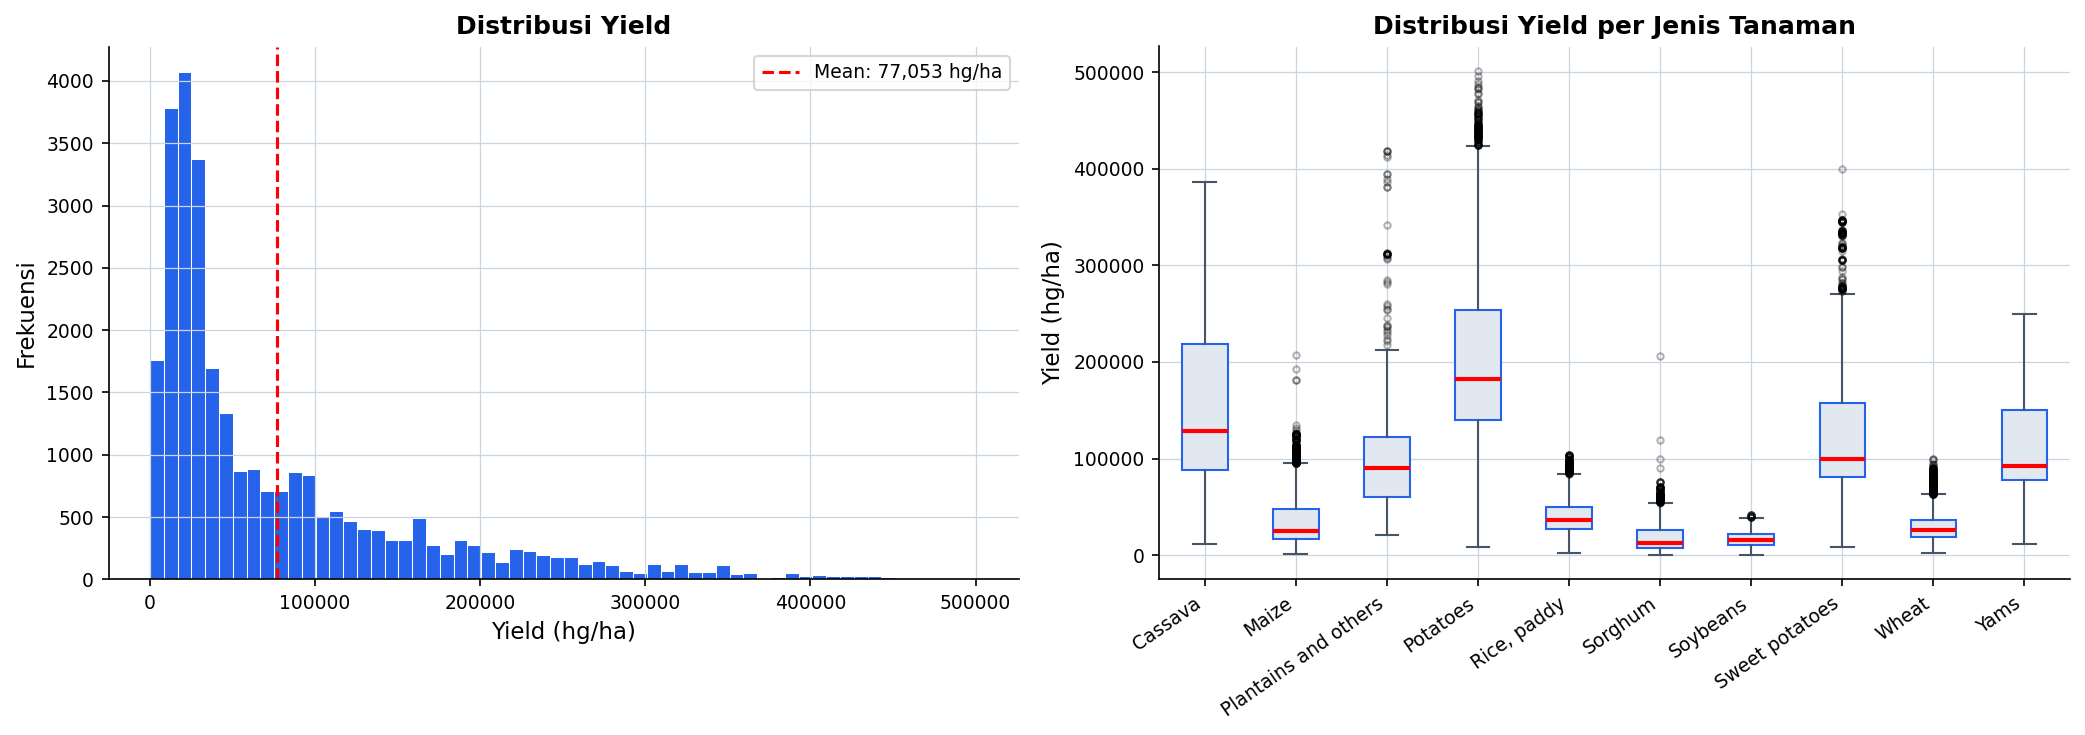

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[COL_YIELD], bins=60, color=BLUE, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Yield (hg/ha)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Yield', fontweight='bold')
mean_v = df[COL_YIELD].mean()
axes[0].axvline(mean_v, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_v:,.0f} hg/ha')
axes[0].legend(fontsize=9)

crops = sorted(df[COL_ITEM].dropna().unique())
data_by_crop = [df[df[COL_ITEM] == c][COL_YIELD].dropna().values for c in crops]
axes[1].boxplot(
    data_by_crop,
    tick_labels=crops,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor=LIGHT, color=BLUE),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color=SLATE),
    capprops=dict(color=SLATE),
    flierprops=dict(marker='o', color=TEAL, alpha=0.3, markersize=3),
)
axes[1].set_xticklabels(crops, rotation=35, ha='right')
axes[1].set_ylabel('Yield (hg/ha)')
axes[1].set_title('Distribusi Yield per Jenis Tanaman', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gambar1_distribusi_yield.png', bbox_inches='tight')
plt.show()

## Gambar 2 - Distribusi 4 Variabel Numerik

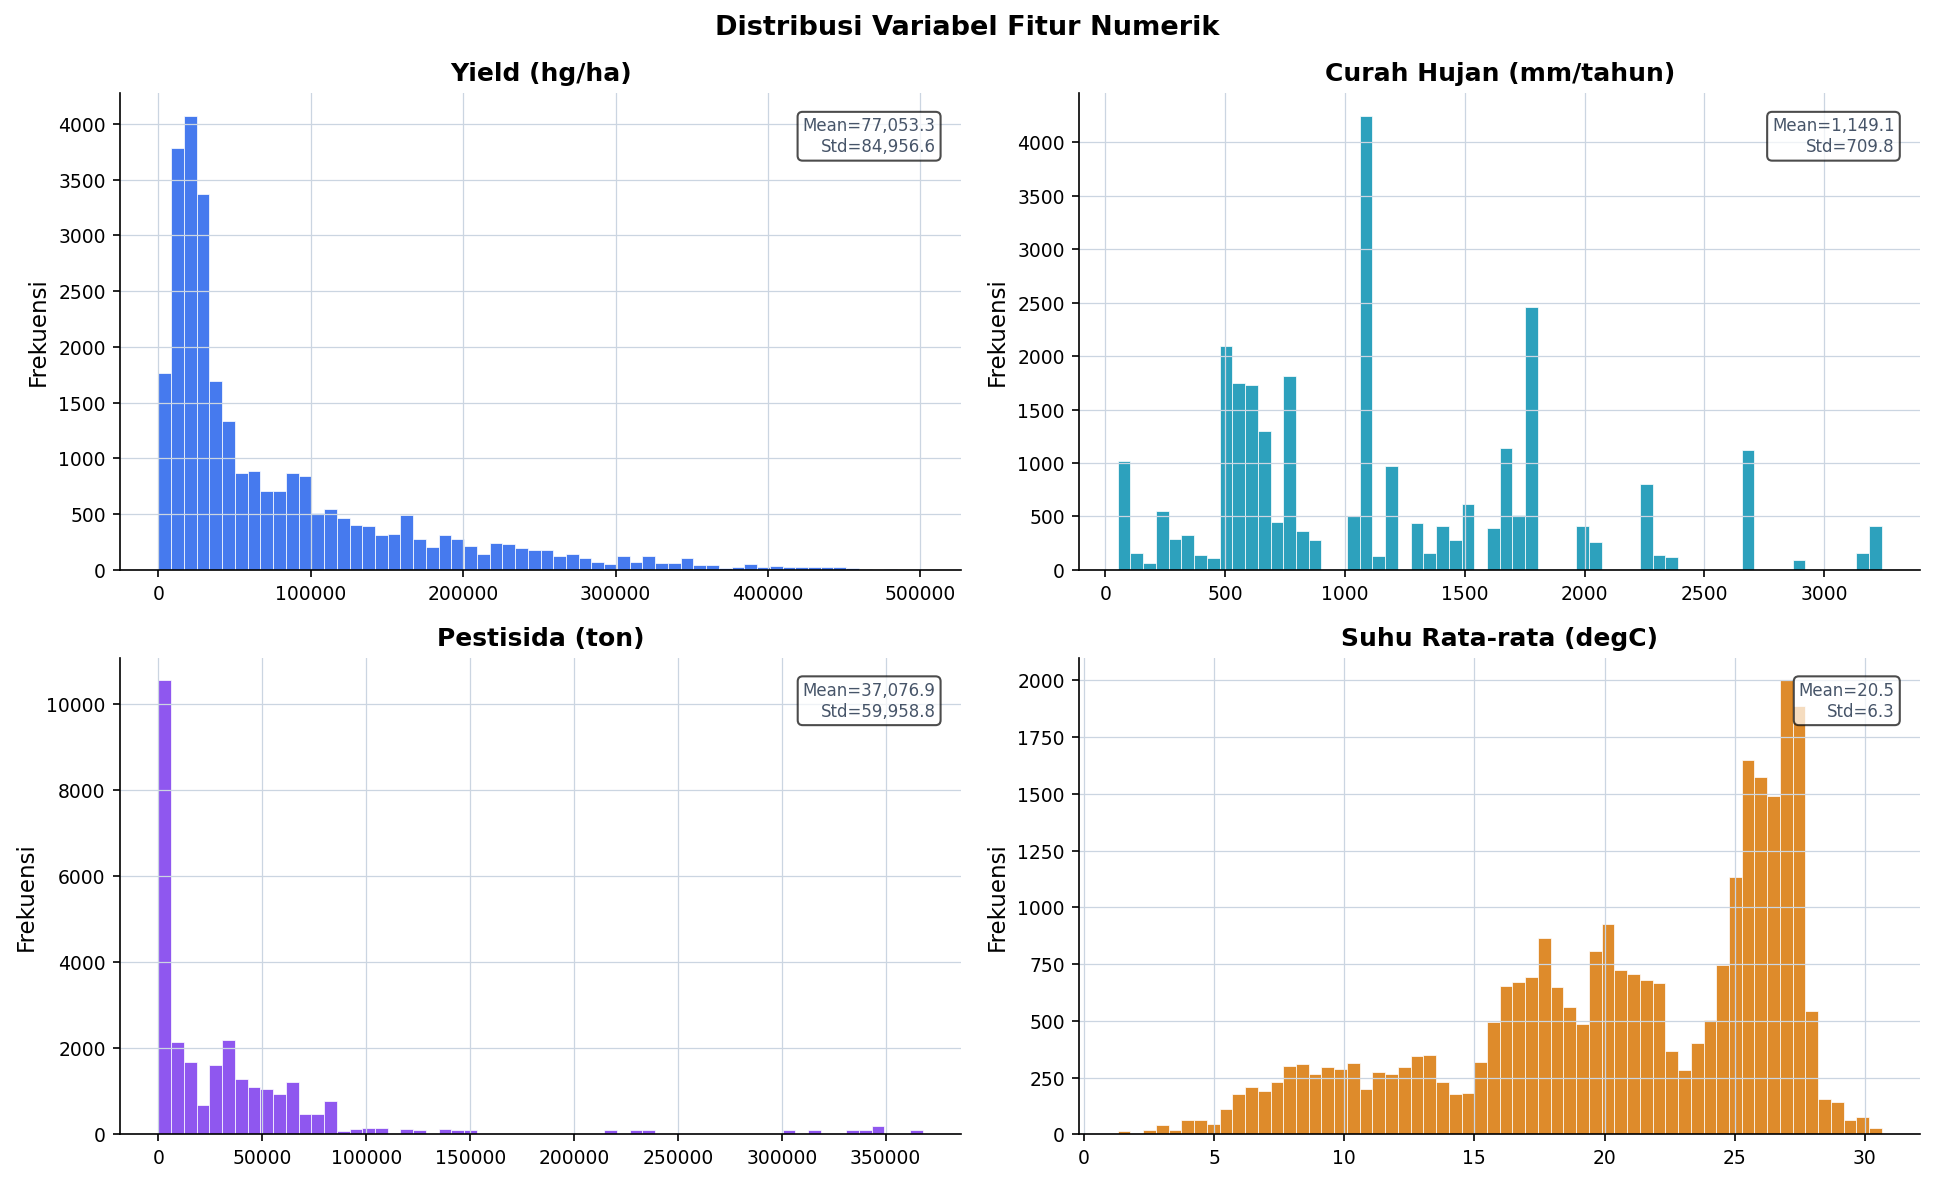

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=60, color=colors[i], edgecolor='white', linewidth=0.4, alpha=0.85)
    axes[i].set_title(col_labels[col], fontweight='bold')
    axes[i].set_ylabel('Frekuensi')
    m, s = df[col].mean(), df[col].std()
    axes[i].text(
        0.97,
        0.95,
        f'Mean={m:,.1f}\nStd={s:,.1f}',
        transform=axes[i].transAxes,
        ha='right',
        va='top',
        fontsize=8,
        color=SLATE,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7),
    )

plt.suptitle('Distribusi Variabel Fitur Numerik', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gambar2_distribusi_fitur.png', bbox_inches='tight')
plt.show()

## Gambar 3 - Missing Values

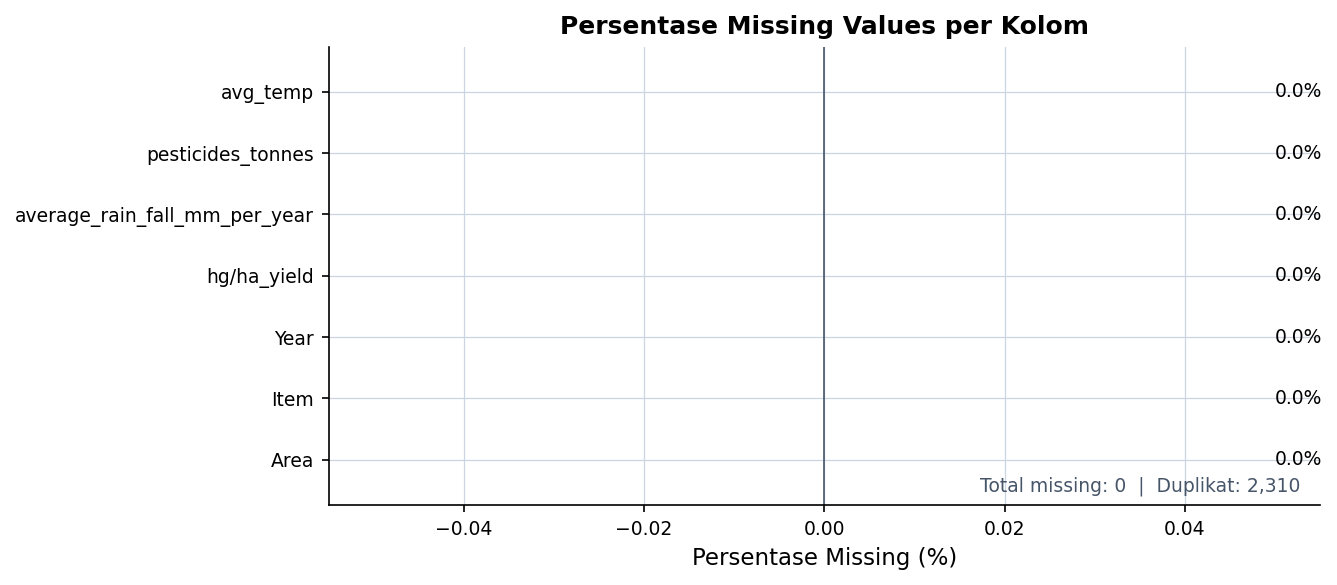

Total baris   : 28242
Total missing : 0
Total duplikat: 2310


In [5]:
miss_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['#EF4444' if v > 0 else TEAL for v in miss_pct.values]
bars = ax.barh(miss_pct.index, miss_pct.values, color=bar_colors, edgecolor='white')
ax.set_xlabel('Persentase Missing (%)')
ax.set_title('Persentase Missing Values per Kolom', fontweight='bold')
ax.axvline(0, color=SLATE, linewidth=0.8)
for bar, v in zip(bars, miss_pct.values):
    ax.text(v + 0.05, bar.get_y() + bar.get_height() / 2, f'{v:.1f}%', va='center', fontsize=9)

total_miss = int(df.isnull().sum().sum())
dup_count = int(df.duplicated().sum())
ax.text(
    0.98,
    0.02,
    f'Total missing: {total_miss:,}  |  Duplikat: {dup_count:,}',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=9,
    color=SLATE,
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gambar3_missing_values.png', bbox_inches='tight')
plt.show()

print('Total baris   :', len(df))
print('Total missing :', total_miss)
print('Total duplikat:', dup_count)

## Gambar 4 - Matriks Korelasi

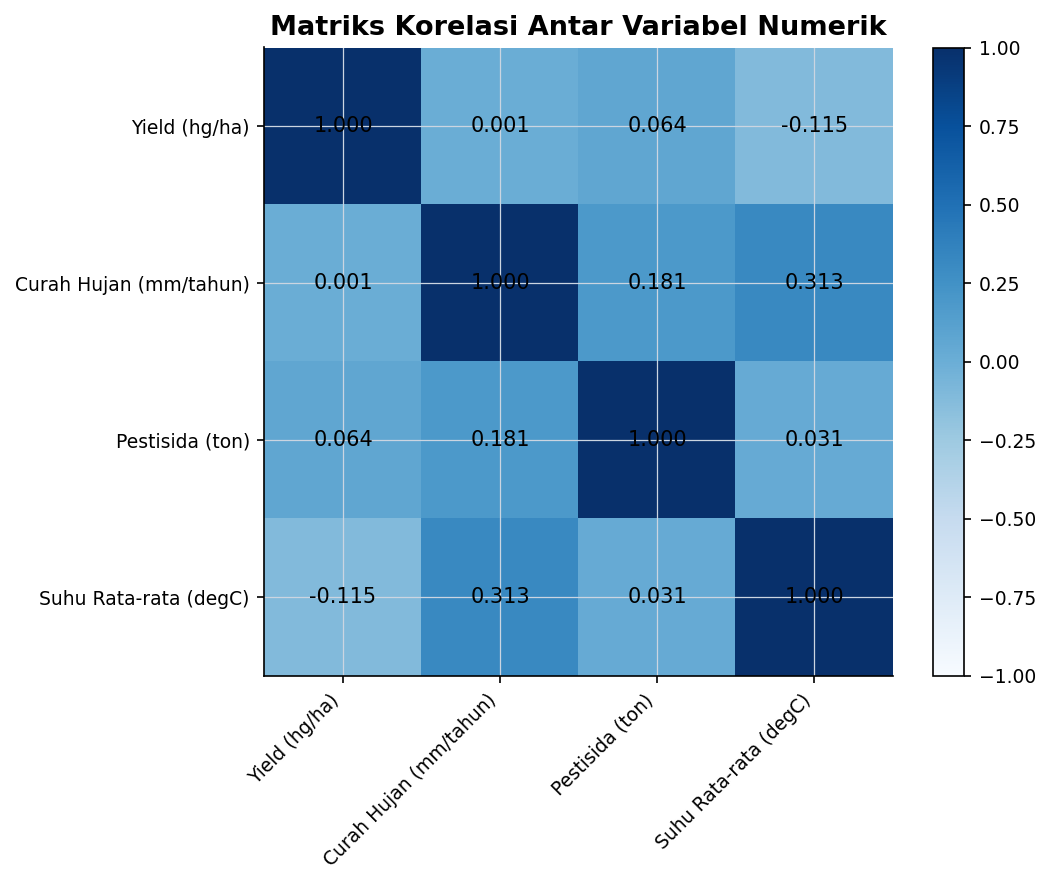

Korelasi dengan Yield:
average_rain_fall_mm_per_year    0.000962
pesticides_tonnes                0.064085
avg_temp                        -0.114777


In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_cols].corr()

if HAVE_SEABORN:
    sns.heatmap(
        corr,
        annot=True,
        fmt='.3f',
        cmap='Blues',
        ax=ax,
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 11, 'weight': 'bold'},
        xticklabels=[col_labels[c] for c in num_cols],
        yticklabels=[col_labels[c] for c in num_cols],
        vmin=-1,
        vmax=1,
        center=0,
    )
else:
    m = corr.values
    im = ax.imshow(m, cmap='Blues', vmin=-1, vmax=1)
    ax.set_xticks(range(len(num_cols)))
    ax.set_yticks(range(len(num_cols)))
    ax.set_xticklabels([col_labels[c] for c in num_cols], rotation=45, ha='right')
    ax.set_yticklabels([col_labels[c] for c in num_cols])
    for i in range(len(num_cols)):
        for j in range(len(num_cols)):
            ax.text(j, i, f'{m[i, j]:.3f}', ha='center', va='center', fontsize=10, color='black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Matriks Korelasi Antar Variabel Numerik', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gambar4_korelasi.png', bbox_inches='tight')
plt.show()

print('Korelasi dengan Yield:')
print(corr[COL_YIELD].drop(COL_YIELD).to_string())

## Gambar 5 - Scatter Plot Fitur vs Yield

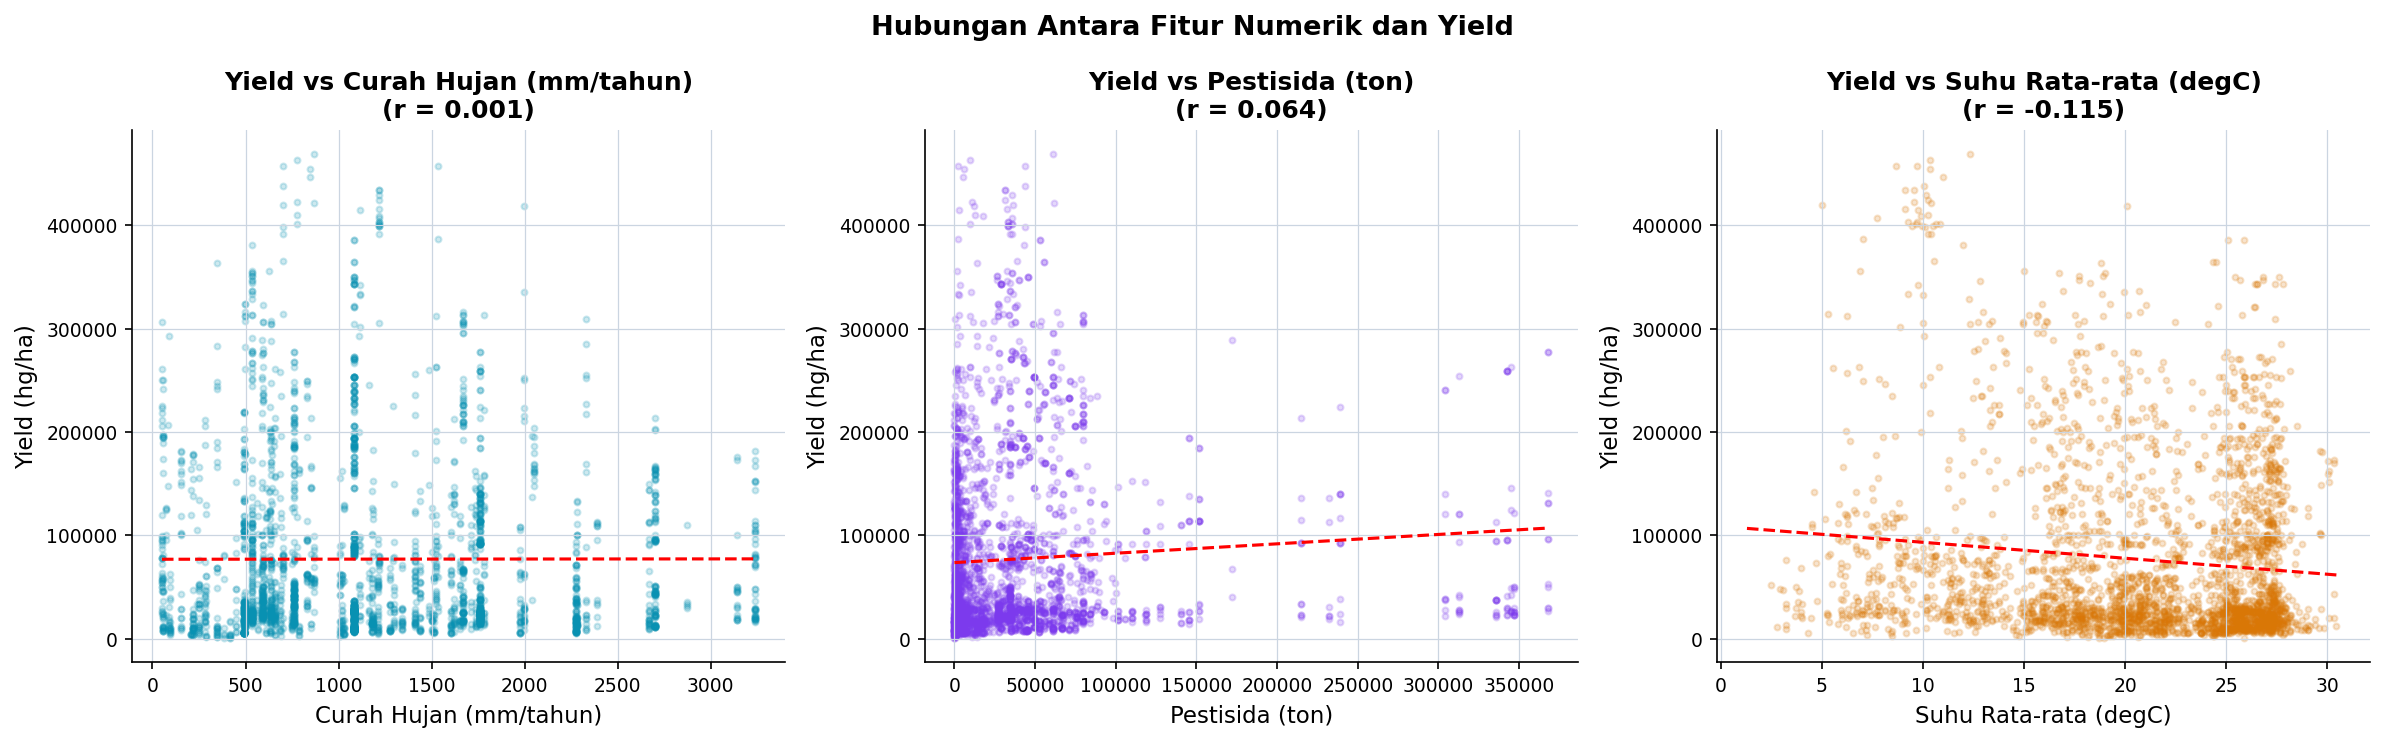

In [7]:
feats = [COL_RAINFALL, COL_PEST, COL_TEMP]
flabels = [col_labels[f] for f in feats]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
MAX_SAMPLE = 3000

for i, (feat, flabel) in enumerate(zip(feats, flabels)):
    sub = df[[feat, COL_YIELD]].dropna()
    samp = sub.sample(min(MAX_SAMPLE, len(sub)), random_state=42)

    axes[i].scatter(samp[feat], samp[COL_YIELD], alpha=0.2, color=colors[i + 1], s=8)

    z = np.polyfit(sub[feat], sub[COL_YIELD], 1)
    p = np.poly1d(z)
    xline = np.linspace(sub[feat].min(), sub[feat].max(), 200)
    axes[i].plot(xline, p(xline), color='red', linewidth=1.5, linestyle='--')

    r = sub[feat].corr(sub[COL_YIELD])
    axes[i].set_xlabel(flabel)
    axes[i].set_ylabel('Yield (hg/ha)')
    axes[i].set_title(f'Yield vs {flabel}\n(r = {r:.3f})', fontweight='bold')

plt.suptitle('Hubungan Antara Fitur Numerik dan Yield', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gambar5_scatter.png', bbox_inches='tight')
plt.show()

## Gambar 6 - Rata-rata Yield per Tanaman + Tren Tahunan

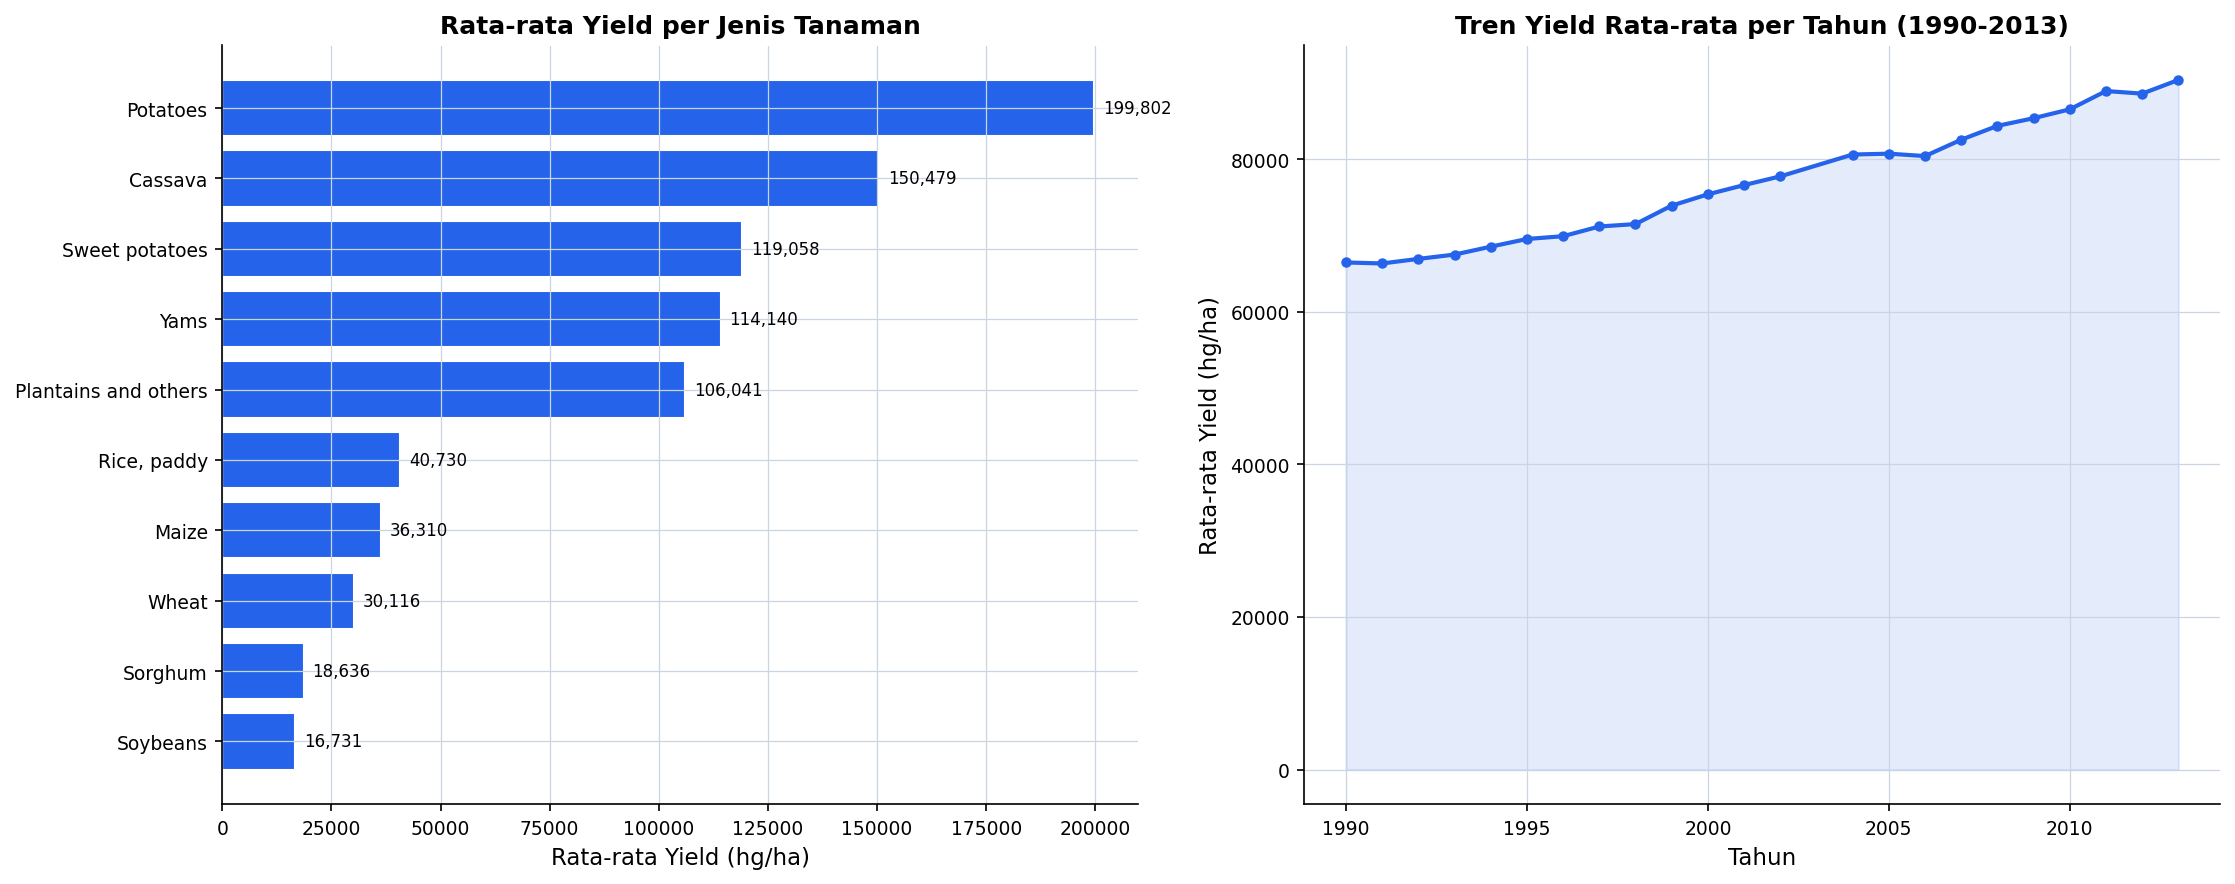

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

crop_means = df.groupby(COL_ITEM)[COL_YIELD].mean().sort_values(ascending=True)
bars = axes[0].barh(crop_means.index, crop_means.values, color=BLUE, edgecolor='white')
axes[0].set_xlabel('Rata-rata Yield (hg/ha)')
axes[0].set_title('Rata-rata Yield per Jenis Tanaman', fontweight='bold')
for bar, v in zip(bars, crop_means.values):
    axes[0].text(v + crop_means.max() * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:,.0f}', va='center', fontsize=8)

yearly = df.groupby(COL_YEAR)[COL_YIELD].mean()
axes[1].plot(yearly.index, yearly.values, color=BLUE, linewidth=2, marker='o', markersize=4)
axes[1].fill_between(yearly.index, yearly.values, alpha=0.12, color=BLUE)
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Rata-rata Yield (hg/ha)')
axes[1].set_title(f'Tren Yield Rata-rata per Tahun ({yearly.index.min()}-{yearly.index.max()})', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gambar6_crop_trend.png', bbox_inches='tight')
plt.show()

## Ringkasan Statistik Deskriptif

In [9]:
display(df[num_cols].describe().round(2))
print('Jumlah negara unik :', df[COL_AREA].nunique())
print('Jumlah tanaman unik:', df[COL_ITEM].nunique())
print('Rentang tahun      :', f"{df[COL_YEAR].min()} - {df[COL_YEAR].max()}")
print('Semua gambar tersimpan di folder:', OUTPUT_DIR)

,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.00,28242.00,28242.00,28242.00
mean,77053.33,1149.06,37076.91,20.54
std,84956.61,709.81,59958.78,6.31
min,50.00,51.00,0.04,1.30
25%,19919.25,593.00,1702.00,16.70
50%,38295.00,1083.00,17529.44,21.51
75%,104676.75,1668.00,48687.88,26.00
max,501412.00,3240.00,367778.00,30.65


Jumlah negara unik : 101
Jumlah tanaman unik: 10
Rentang tahun      : 1990 - 2013
Semua gambar tersimpan di folder: figures
